# Train PubMedBERT for DDI NLI Task

This notebook fine-tunes PubMedBERT on your synthetic DDI dataset for Natural Language Inference.

**Task**: Given a premise (original DDI text) and hypothesis (synthetic summary), predict:
- `entailment` - hypothesis follows from premise
- `contradiction` - hypothesis contradicts premise  
- `neutral` - hypothesis is unrelated to premise

In [1]:
import torch
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from tqdm import tqdm

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)
from datasets import Dataset

device = (
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using device: {device}")

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")

Using device: cpu
PyTorch version: 2.11.0
CUDA available: False


In [2]:
# ═══════════════════════════════════════════════════════════════
# CONFIGURATION
# ═══════════════════════════════════════════════════════════════

# Model
MODEL_NAME = "microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext"
MAX_LENGTH = 256

# Training
BATCH_SIZE = 16
LEARNING_RATE = 2e-5
EPOCHS = 3
RANDOM_SEED = 42

# Data
DATA_FILE = "synthetic_rag_dataset_groq.csv" 
TEST_SIZE = 0.2

# Output
OUTPUT_DIR = "./ddi_nli_pubmedbert"

# Label mapping
LABEL2ID = {"entailment": 0, "contradiction": 1, "neutral": 2}
ID2LABEL = {0: "entailment", 1: "contradiction", 2: "neutral"}

print(f"Model: {MODEL_NAME}")
print(f"Labels: {LABEL2ID}")

Model: microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext
Labels: {'entailment': 0, 'contradiction': 1, 'neutral': 2}


In [3]:
# ═══════════════════════════════════════════════════════════════
# LOAD DATA
# ═══════════════════════════════════════════════════════════════

# Load your synthetic dataset
df = pd.read_csv(DATA_FILE)

print(f"Total samples: {len(df)}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nLabel distribution:")
print(df['scenario'].value_counts())

Total samples: 6323

Columns: ['original_id', 'source', 'e1_text', 'e2_text', 'premise', 'synthetic_rag_output', 'interaction_type', 'scenario', 'model']

Label distribution:
scenario
entailment       1581
contradiction    1581
neutral          1581
fake_drug        1580
Name: count, dtype: int64


In [4]:
# ═══════════════════════════════════════════════════════════════
# PREPARE DATA FOR NLI
# ═══════════════════════════════════════════════════════════════

# Map scenario to NLI label
SCENARIO_TO_LABEL = {
    "entailment": "entailment",
    "contradiction": "contradiction", 
    "neutral": "neutral",
    "fake_drug": "neutral"
}

# Create NLI dataset
df_nli = pd.DataFrame({
    'premise': df['premise'],
    'hypothesis': df['synthetic_rag_output'],
    'label': df['scenario'].map(SCENARIO_TO_LABEL).map(LABEL2ID)
})

# Remove any rows with NaN
df_nli = df_nli.dropna()

print(f"NLI samples: {len(df_nli)}")
print(f"\nLabel distribution:")
print(df_nli['label'].value_counts())

NLI samples: 6301

Label distribution:
label
2    3150
0    1578
1    1573
Name: count, dtype: int64


In [5]:
# ═══════════════════════════════════════════════════════════════
# TRAIN/TEST SPLIT
# ═══════════════════════════════════════════════════════════════

train_df, test_df = train_test_split(
    df_nli, 
    test_size=TEST_SIZE, 
    random_state=RANDOM_SEED,
    stratify=df_nli['label']
)

print(f"Train samples: {len(train_df)}")
print(f"Test samples: {len(test_df)}")
print(f"\nTrain label distribution:")
print(train_df['label'].value_counts())

Train samples: 5040
Test samples: 1261

Train label distribution:
label
2    2520
0    1262
1    1258
Name: count, dtype: int64


In [6]:
# ═══════════════════════════════════════════════════════════════
# LOAD TOKENIZER & MODEL
# ═══════════════════════════════════════════════════════════════

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Load model with 3 labels (entailment, contradiction, neutral)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label=ID2LABEL,
    label2id=LABEL2ID
)

print(f"Model loaded: {MODEL_NAME}")
print(f"Max length: {MAX_LENGTH}")
print(f"Number of labels: 3")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect ide

Model loaded: microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext
Max length: 256
Number of labels: 3


In [7]:
# ═══════════════════════════════════════════════════════════════
# TOKENIZE DATA
# ═══════════════════════════════════════════════════════════════

def tokenize_function(examples):
    """Tokenize premise-hypothesis pairs for NLI"""
    return tokenizer(
        examples['premise'],
        examples['hypothesis'],
        truncation=True,
        max_length=MAX_LENGTH,
        padding=False  
    )

# Convert to HuggingFace Dataset
train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

# Tokenize
train_dataset = train_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

# Remove text columns (keep only tokenized inputs)
train_dataset = train_dataset.remove_columns(['premise', 'hypothesis'])
test_dataset = test_dataset.remove_columns(['premise', 'hypothesis'])

# Rename label column
train_dataset = train_dataset.rename_column('label', 'labels')
test_dataset = test_dataset.rename_column('label', 'labels')

print(f"Train dataset: {train_dataset}")
print(f"Test dataset: {test_dataset}")

Map:   0%|          | 0/5040 [00:00<?, ? examples/s]

Map:   0%|          | 0/1261 [00:00<?, ? examples/s]

Train dataset: Dataset({
    features: ['labels', '__index_level_0__', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 5040
})
Test dataset: Dataset({
    features: ['labels', '__index_level_0__', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 1261
})


In [8]:
# ═══════════════════════════════════════════════════════════════
# DEFINE METRICS
# ═══════════════════════════════════════════════════════════════

def compute_metrics(eval_pred):
    """Compute accuracy and other metrics"""
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    
    acc = accuracy_score(labels, predictions)
    
    return {
        'accuracy': acc
    }

print("Metrics function defined")

Metrics function defined


In [ ]:
# ═══════════════════════════════════════════════════════════════
# TRAINING SETUP
# ═══════════════════════════════════════════════════════════════

# Data collator for dynamic padding
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# Training arguments
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    logging_steps=10,
    seed=RANDOM_SEED,
    # fp16=torch.cuda.is_available(),  # Use mixed precision if GPU available
    ##config macos heinrich ganteng

)

# Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print("Trainer configured")
print(f"Epochs: {EPOCHS}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Learning rate: {LEARNING_RATE}")

Trainer configured
Epochs: 3
Batch size: 16
Learning rate: 2e-05


In [11]:
# ═══════════════════════════════════════════════════════════════
# TRAIN MODEL
# ═══════════════════════════════════════════════════════════════

print("Starting training...")
trainer.train()
print("Training complete!")

Starting training...


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy
1,0.003553,0.074227,0.985726
2,0.028569,0.039411,0.992863
3,0.003689,0.046670,0.992863


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training complete!


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Epoch,Accuracy
0.003689,0.039411,3,0.992863



Evaluation Results:
  eval_loss: 0.0394
  eval_accuracy: 0.9929


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



Confusion Matrix:
[[312   4   0]
 [  4 311   0]
 [  1   0 629]]


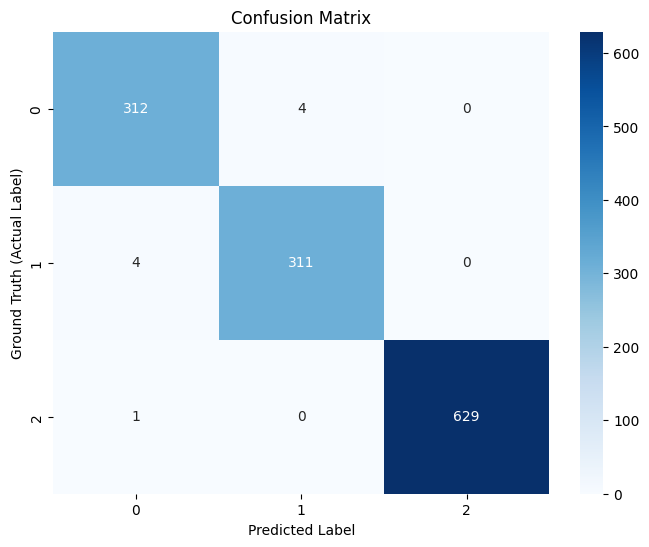


Per-Class Classification Report:
              precision    recall  f1-score   support

           0     0.9842    0.9873    0.9858       316
           1     0.9873    0.9873    0.9873       315
           2     1.0000    0.9984    0.9992       630

    accuracy                         0.9929      1261
   macro avg     0.9905    0.9910    0.9908      1261
weighted avg     0.9929    0.9929    0.9929      1261



In [13]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ═══════════════════════════════════════════════════════════════
# EVALUATE MODEL
# ═══════════════════════════════════════════════════════════════

results = trainer.evaluate()
print(f"\nEvaluation Results:")
for key, value in results.items():
    if isinstance(value, float):
        print(f"  {key}: {value:.4f}")

predictions = trainer.predict(test_dataset)
y_pred = np.argmax(predictions.predictions, axis=1)
y_true = predictions.label_ids

# 3. Generate Confusion Matrix (TP, TN, FP, FN)
cm = confusion_matrix(y_true, y_pred)
print("\nConfusion Matrix:")
print(cm)

# Optional: Plot Confusion Matrix visually
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('Ground Truth (Actual Label)')
plt.title('Confusion Matrix')
plt.show()

print("\nPer-Class Classification Report:")
print(classification_report(y_true, y_pred, digits=4))

In [ ]:
# ═══════════════════════════════════════════════════════════════
# DETAILED CLASSIFICATION REPORT
# ═══════════════════════════════════════════════════════════════

# Get predictions
predictions = trainer.predict(test_dataset)
y_pred = np.argmax(predictions.predictions, axis=-1)
y_true = predictions.label_ids

# Classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=['entailment', 'contradiction', 'neutral']))

In [ ]:
# ═══════════════════════════════════════════════════════════════
# SAVE MODEL
# ═══════════════════════════════════════════════════════════════

# Save model and tokenizer
trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

print(f"Model saved to: {OUTPUT_DIR}")

In [ ]:
# ═══════════════════════════════════════════════════════════════
# TEST INFERENCE
# ═══════════════════════════════════════════════════════════════

def predict_nli(premise, hypothesis):
    """Predict NLI label for a premise-hypothesis pair"""
    # Tokenize
    inputs = tokenizer(
        premise,
        hypothesis,
        truncation=True,
        max_length=MAX_LENGTH,
        return_tensors="pt"
    )
    
    # Move to same device as model
    inputs = {k: v.to(model.device) for k, v in inputs.items()}
    
    # Predict
    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.softmax(outputs.logits, dim=-1)
        pred_id = torch.argmax(probs, dim=-1).item()
    
    return {
        'label': ID2LABEL[pred_id],
        'confidence': probs[0][pred_id].item(),
        'probabilities': {
            'entailment': probs[0][0].item(),
            'contradiction': probs[0][1].item(),
            'neutral': probs[0][2].item()
        }
    }

# Test examples
test_examples = [
    {
        "premise": "The metabolism of Warfarin decreases when combined with Fluconazole.",
        "hypothesis": "Fluconazole slows down Warfarin metabolism."
    },
    {
        "premise": "The metabolism of Warfarin decreases when combined with Fluconazole.",
        "hypothesis": "No interaction exists between Warfarin and Fluconazole."
    },
    {
        "premise": "The metabolism of Warfarin decreases when combined with Fluconazole.",
        "hypothesis": "Warfarin is an anticoagulant and Fluconazole is an antifungal."
    }
]

print("\n" + "="*60)
print("TEST INFERENCE")
print("="*60)

for i, ex in enumerate(test_examples, 1):
    result = predict_nli(ex['premise'], ex['hypothesis'])
    print(f"\nExample {i}:")
    print(f"  Premise: {ex['premise']}")
    print(f"  Hypothesis: {ex['hypothesis']}")
    print(f"  → Prediction: {result['label']} (confidence: {result['confidence']:.2%})")
    print(f"  → Probabilities: {result['probabilities']}")

In [ ]:
# ═══════════════════════════════════════════════════════════════
# TRAINING SUMMARY
# ═══════════════════════════════════════════════════════════════

print("\n" + "="*60)
print("TRAINING SUMMARY")
print("="*60)
print(f"Model: {MODEL_NAME}")
print(f"Training samples: {len(train_df)}")
print(f"Test samples: {len(test_df)}")
print(f"Epochs: {EPOCHS}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Test accuracy: {results['eval_accuracy']:.2%}")
print(f"\nModel saved to: {OUTPUT_DIR}")
print("\nTo load the model later:")
print(f"  model = AutoModelForSequenceClassification.from_pretrained('{OUTPUT_DIR}')")
print(f"  tokenizer = AutoTokenizer.from_pretrained('{OUTPUT_DIR}')")